In [1]:

"""
The purpose of this script is to create an input folder for the ParFlow model.

It is created very similarly to the ISWS State Fair model (indicator file), including
.pfb and .pfb.dist folders.


Hydrological units in the ParFlow contaminant transport model are the same as in the ISWS State Fair model.

.pfb input == optimizes files for how Parflow represents and processes 3D hydrologic fields.

September 15, 2025

Author(s): ISWS; alljones,esrag""" 

## Parflow imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import shapely
from parflowio.pyParflowio import PFData
from parflow import Run
from parflow.tools.fs import get_absolute_path
from parflow.tools.io import write_pfb, read_pfb
from shapely import Polygon
from modules import find_cells_within_polygon
from parflowio.pyParflowio import PFData

# Create numpy array
topodata = pd.read_excel("./inputs/topology.xlsx")
# mpk = input_file.loc[:,['x_coord', 'z_coord']].to_numpy() 

In [2]:
topopoly = {}
for id in np.unique(topodata.id):
    data = topodata[topodata.id == id]
    topopoly[id] = Polygon([(xxx, zzz) for xxx, zzz in zip(data.x_coord, data.z_coord)])
print(topopoly[id])

POLYGON ((0 11.8, 0 14.3, 24.5 19.5, 51.2 22.6, 51.2 17.8, 48.2 17.3, 7.8 12.900000000000002, 0 11.8))


In [3]:

NX = 100
NY = 3
NZ = 60

l_z = 29.8 # cm
l_x = 51.2 # cm
l_y = 2.54 # cm

DX = l_x/NX
DY = l_y/NY
DZ = l_z/NZ

x_cell_centers = np.arange(DX/2, l_x, DX)
z_cell_centers = np.arange(DZ/2, l_z, DZ)

gridx, gridz = np.meshgrid(x_cell_centers, z_cell_centers)

indicator = np.ones((NZ, NY, NX))*-999
holder = np.ones((NZ, NX))*-888

# defines geology of cross-section
for n, id in enumerate(topopoly.keys()):
    idx = find_cells_within_polygon(topopoly[id], gridx, gridz)
    n+=1
    if id == 'inactive':
        n = 0
    holder[idx] = n
    print(n, id)

# propagates cross-section through the model "rows"
for y in range(NY):
    indicator[:,y,:] = holder

1 aquiclude_1
2 aquiclude_2
3 aquitard
4 clay_layer_1
5 clay_layer_2
6 confined_artesian_aquifer
7 fine_sand
8 fractured_bedrock
0 inactive
10 river_channel
11 soil_zone
12 unconfined_aquifer


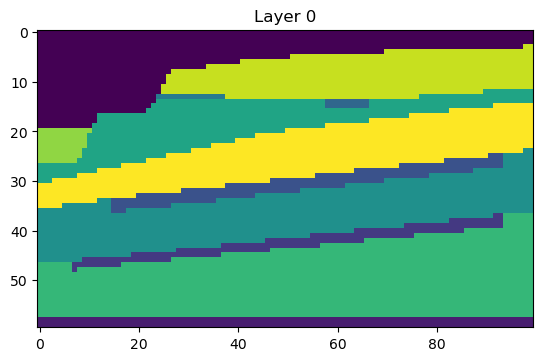

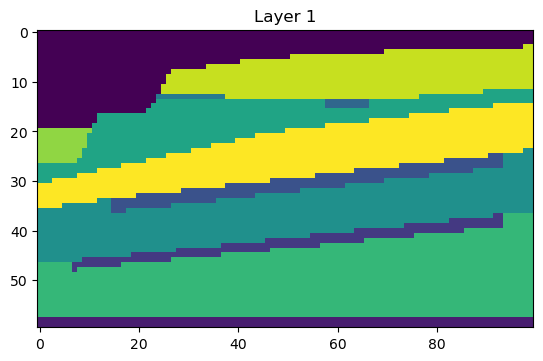

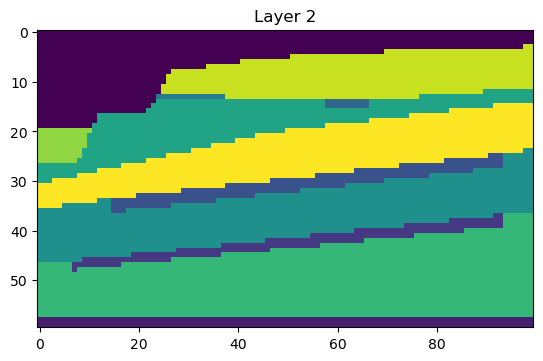

In [4]:
for y in range(NY):
    plt.figure(y)
    plt.imshow(np.flipud(indicator[:, y,:]))
    plt.title(f'Layer {y}')
    plt.show()

In [5]:

# Write flow boundary file as PFB with write_pfb() function
write_pfb(get_absolute_path('./inputs/contamination_model.pfb'), indicator)

In [6]:
model_indicator = PFData('./inputs/contamination_model.pfb')
model_indicator.loadHeader()
model_indicator.loadData()
model_indicator_data = model_indicator.viewDataArray()

print(f'Dimensions of output file: {model_indicator_data.shape}')



Dimensions of output file: (60, 3, 100)


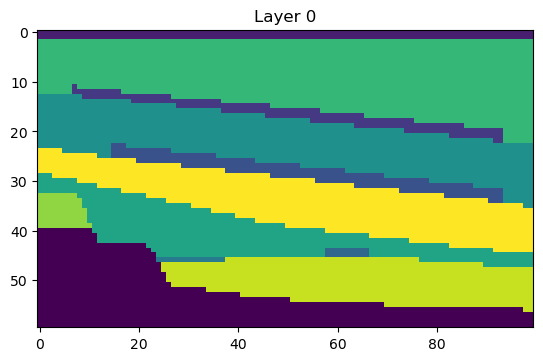

In [7]:
for l in range(1):
    plt.figure(l)
    plt.imshow(model_indicator_data[:, l,:])
    plt.title(f'Layer {l}')
    plt.show()